## Supplementary Materials: Mixed-Effects Models for Study 1 & Study 2

## 1. Setup

### 1.1 Load Packages

In [1]:
# Load required packages
suppressPackageStartupMessages({
  library(tidyverse)  # for data manipulation and visualization
  library(lme4)       # for mixed-effects models
  library(lmerTest)   # for p-values in lmer
  library(emmeans)    # for pairwise comparisons
  library(glmmTMB)    # for GLMMs
  library(DHARMa)     # for model diagnostics
  library(patchwork)  # for combining plots
})

# Source utility scripts
source("utils/r_utils.R")
source("utils/r_plotting_utils.R")

# Resize plots and suppress warnings for cleaner output
options(
  repr.plot.width  = 10,
  repr.plot.height = 5,
  repr.plot.res    = 150,
  warn = -1
)
emm_options(msg.interaction = FALSE)

### 1.2 Study Configuration

Define study-specific parameters (including conditions, SPL mappings, environment levels).

In [2]:
# --- Study 1 Configuration ---
study1_config <- list(
  study_id = "study1",
  cc_file = "final datasets/study1/study1_cc_models.csv",
  environments = c("Library", "Living", "Cafe", "Train", "FoodCourt", "NoMusicParty", "MusicParty"),
  spl_map = c(
    Library      = 53.0,
    Living       = 63.3,
    Cafe         = 71.7,
    Train        = 77.1,
    FoodCourt    = 79.6,
    NoMusicParty = 85.0,
    MusicParty   = 92.0
  ),
  spl_range = c(50, 95),
  has_condition = TRUE,
  n_environments = 7
)

# --- Study 2 Configuration ---
study2_config <- list(
  study_id = "study2",
  cc_file = "final datasets/study2/study2_cc_models.csv",
  environments = c("Office", "Cafe", "Food", "Party"),
  spl_map = c(
    Office = 60.0,
    Cafe   = 70.0,
    Food   = 80.0,
    Party  = 87.5
  ),
  spl_range = c(55, 90),
  has_condition = FALSE,
  n_environments = 4
)

# Print configurations
cat("Study 1:", study1_config$n_environments, "environments, SPL range:", 
    study1_config$spl_range[1], "-", study1_config$spl_range[2], "dB\n")
cat("Study 2:", study2_config$n_environments, "environments, SPL range:", 
    study2_config$spl_range[1], "-", study2_config$spl_range[2], "dB\n")

Study 1: 7 environments, SPL range: 50 - 95 dB
Study 2: 4 environments, SPL range: 55 - 90 dB


### 1.3. Load Data for Both Studies

In [3]:
# Load dyadic (cross-correlation) data
cm_df1 <- load_dyadic_data(study1_config)
cm_df2 <- load_dyadic_data(study2_config)

# Quick data check
cat("Study 1 - CC data:", nrow(cm_df1), "rows\n")
cat("Study 2 - CC data:", nrow(cm_df2), "rows\n")

Study 1 - CC data: 1232 rows
Study 2 - CC data: 1100 rows


## 2. Complexity Matching Analysis

### 2.1 Study 1: CM ~ Pair Type

In [4]:
# Filter to environmental correlations only
cm_df1_env <- cm_df1 %>% filter(corr_type == "stimulus")

# Model
m1_cm_cat <- lmer(alpha_corr_z ~ pair_type + (1 | pair), data = cm_df1_env)
summary(m1_cm_cat)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: alpha_corr_z ~ pair_type + (1 | pair)
   Data: cm_df1_env

REML criterion at convergence: 107

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.4270 -0.6112  0.0453  0.6056  4.0854 

Random effects:
 Groups   Name        Variance Std.Dev.
 pair     (Intercept) 0.005267 0.07257 
 Residual             0.065710 0.25634 
Number of obs: 616, groups:  pair, 22

Fixed effects:
                 Estimate Std. Error        df t value Pr(>|t|)  
(Intercept)       0.04032    0.02128  35.82124   1.895   0.0662 .
pair_typeactual   0.03033    0.02066 593.00000   1.468   0.1425  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr)
pair_typctl -0.485

### 2.2 Study 2: CM ~ Pair Type

In [5]:
# Filter to environmental correlations only
cm_df2_env <- cm_df2 %>% filter(corr_type == "stimulus")

# Model
m2_cm_cat <- lmer(alpha_corr_z ~ pair_type + (1 | pair), data = cm_df2_env)
summary(m2_cm_cat)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: alpha_corr_z ~ pair_type + (1 | pair)
   Data: cm_df2_env

REML criterion at convergence: -576

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.9994 -0.6017  0.0250  0.5940  3.3744 

Random effects:
 Groups   Name        Variance Std.Dev.
 pair     (Intercept) 0.001053 0.03245 
 Residual             0.017291 0.13149 
Number of obs: 502, groups:  pair, 46

Fixed effects:
                 Estimate Std. Error        df t value Pr(>|t|)  
(Intercept)     2.030e-02  9.309e-03 1.014e+02   2.181   0.0315 *
pair_typeactual 9.493e-03  1.185e-02 4.750e+02   0.801   0.4237  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr)
pair_typctl -0.576

## 3. RMS Cross-Correlation Analysis

### 3.1 Study 1: RMS Corr ~ Pair Type

boundary (singular) fit: see help('isSingular')



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: rms_corr_z ~ pair_type + (1 | pair)
   Data: cm_df1_env

REML criterion at convergence: 215.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.8420 -0.5033 -0.0252  0.5393  3.7615 

Random effects:
 Groups   Name        Variance Std.Dev.
 pair     (Intercept) 0.00000  0.0000  
 Residual             0.08165  0.2858  
Number of obs: 616, groups:  pair, 22

Fixed effects:
                 Estimate Std. Error        df t value Pr(>|t|)  
(Intercept)       0.01551    0.01628 614.00000   0.952   0.3413  
pair_typeactual   0.04911    0.02303 614.00000   2.133   0.0333 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr)
pair_typctl -0.707
optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singular) fit: see help('isSingular')



Call:
lm(formula = rms_corr_z ~ pair_type, data = cm_df1_env)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.09785 -0.14382 -0.00721  0.15411  1.07484 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)  
(Intercept)      0.01551    0.01628   0.952   0.3413  
pair_typeactual  0.04911    0.02303   2.133   0.0333 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.2858 on 614 degrees of freedom
Multiple R-squared:  0.007354,	Adjusted R-squared:  0.005738 
F-statistic: 4.549 on 1 and 614 DF,  p-value: 0.03333


,pair_type,emmean,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,pseudo,0.01550546,0.01628214,614,-0.01646997,0.04748090,0.952299,3.413201e-01
2,actual,0.06461744,0.01628214,614,0.03264200,0.09659287,3.968609,8.083712e-05


 contrast        estimate    SE  df t.ratio p.value
 pseudo - actual  -0.0491 0.023 614  -2.133  0.0333


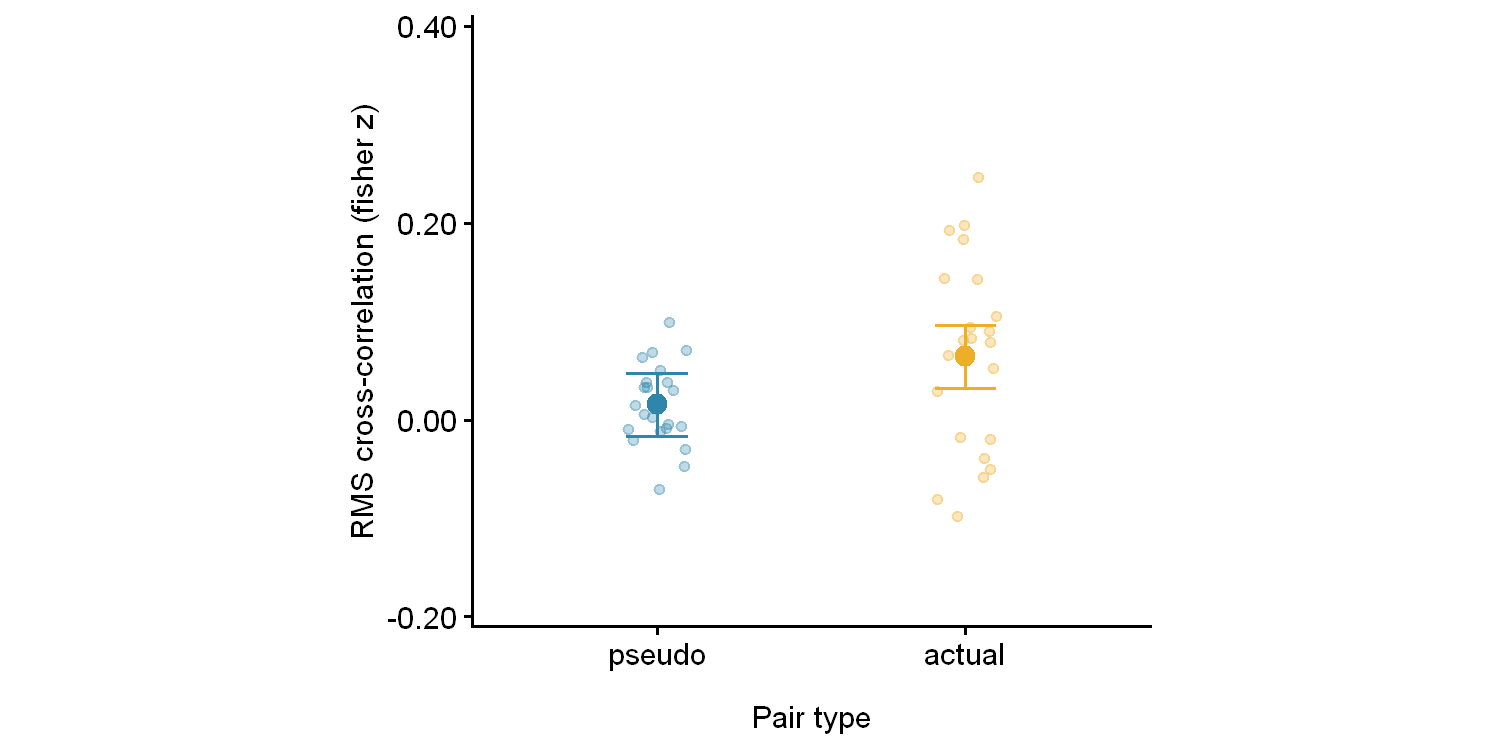

In [6]:
# Model
## Pair random effect returns singular fit, indicating no between-pair variance
m1_rms_cat <- lmer(rms_corr_z ~ pair_type + (1 | pair), data = cm_df1_env)
summary(m1_rms_cat)

# Using fixed effects model instead
m1_rms_cat <- lm(rms_corr_z ~ pair_type, data = cm_df1_env)
summary(m1_rms_cat)

# Estimated marginal means
emm_s1_rms_cat <- emmeans(m1_rms_cat, ~ pair_type, infer = c(TRUE, TRUE))
emm_s1_rms_cat_df <- as.data.frame(emm_s1_rms_cat)
emm_s1_rms_cat_df

# Pairwise comparisons
pairs(emm_s1_rms_cat, by = NULL, adjust = "tukey")

# Create plot using helper function
p_rms_cat_s1 <- create_pair_type_plot(
  dyad_data = cm_df1_env,
  value_var = "rms_corr_z",
  emm_df = emm_s1_rms_cat_df,
  ylabel = "RMS cross-correlation (fisher z)",
  ylim_min = -0.21,
  ylim_max = 0.41
)

print(p_rms_cat_s1)

### 3.2 Study 2: RMS Corr ~ Pair Type

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: rms_corr_z ~ pair_type + (1 | pair)
   Data: cm_df2_env

REML criterion at convergence: -563.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.7874 -0.6577 -0.0369  0.5521  3.3529 

Random effects:
 Groups   Name        Variance  Std.Dev.
 pair     (Intercept) 0.0006239 0.02498 
 Residual             0.0180351 0.13429 
Number of obs: 502, groups:  pair, 46

Fixed effects:
                 Estimate Std. Error        df t value Pr(>|t|)  
(Intercept)     1.756e-03  8.944e-03 1.104e+02   0.196   0.8447  
pair_typeactual 3.112e-02  1.208e-02 4.753e+02   2.576   0.0103 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr)
pair_typctl -0.613

,pair_type,emmean,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,pseudo,0.001756197,0.008944299,112.1548,-0.01596552,0.01947791,0.1963482,0.8446929649
2,actual,0.032877731,0.009675749,130.0159,0.01373544,0.05202002,3.3979522,0.0009014812


 contrast        estimate     SE  df t.ratio p.value
 pseudo - actual  -0.0311 0.0121 476  -2.574  0.0104

Degrees-of-freedom method: kenward-roger 

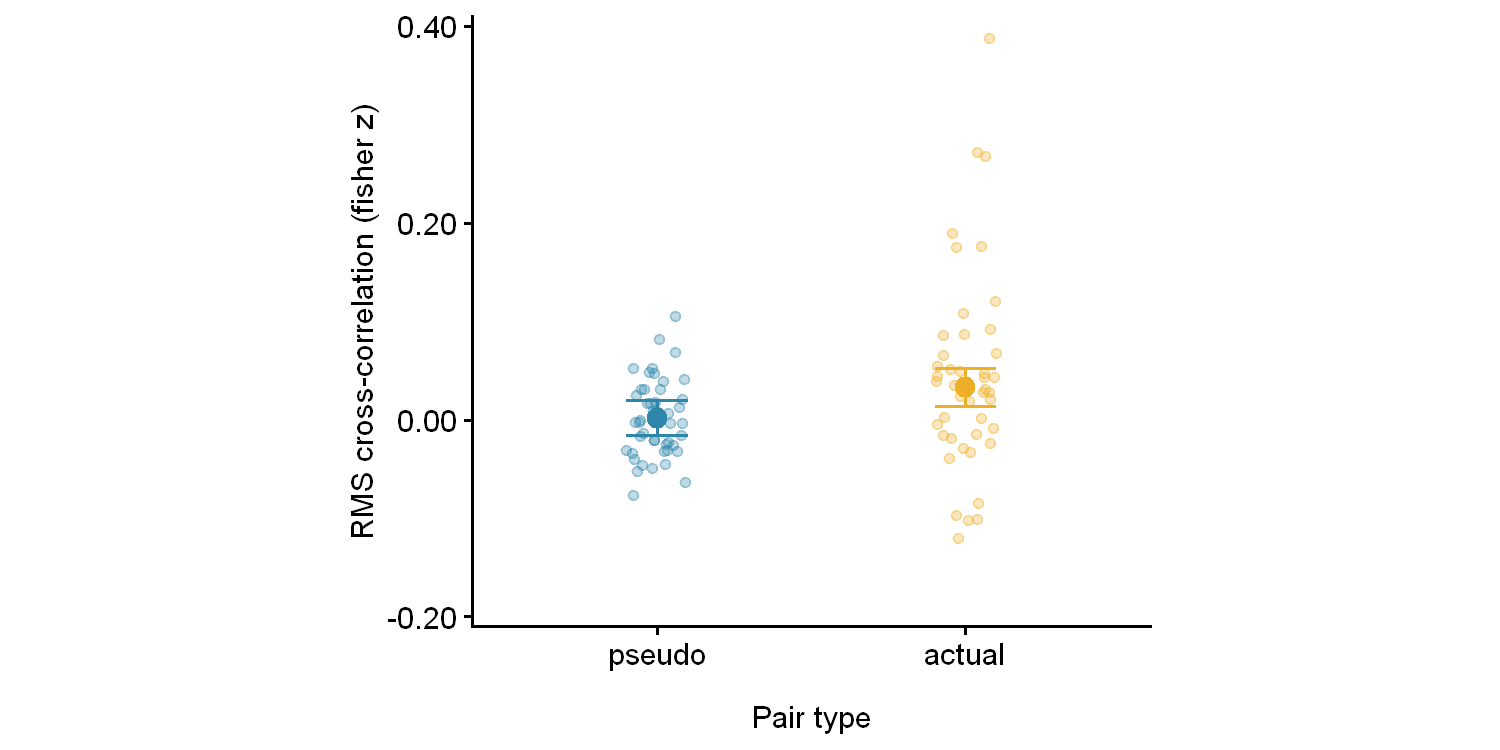

In [7]:
# Model
m2_rms_cat <- lmer(rms_corr_z ~ pair_type + (1 | pair), data = cm_df2_env)
summary(m2_rms_cat)

# Estimated marginal means
emm_s2_rms_cat <- emmeans(m2_rms_cat, ~ pair_type, infer = c(TRUE, TRUE))
emm_s2_rms_cat_df <- as.data.frame(emm_s2_rms_cat)
emm_s2_rms_cat_df

# Pairwise comparisons
pairs(emm_s2_rms_cat, by = NULL, adjust = "tukey")

# Create plot using helper function
p_rms_cat_s2 <- create_pair_type_plot(
  dyad_data = cm_df2_env,
  value_var = "rms_corr_z",
  emm_df = emm_s2_rms_cat_df,
  ylabel = "RMS cross-correlation (fisher z)",
  ylim_min = -0.21,
  ylim_max = 0.41
)

print(p_rms_cat_s2)

### 3.3 Combined Multi-Panel Figure: RMS Cross-Correlation Comparison

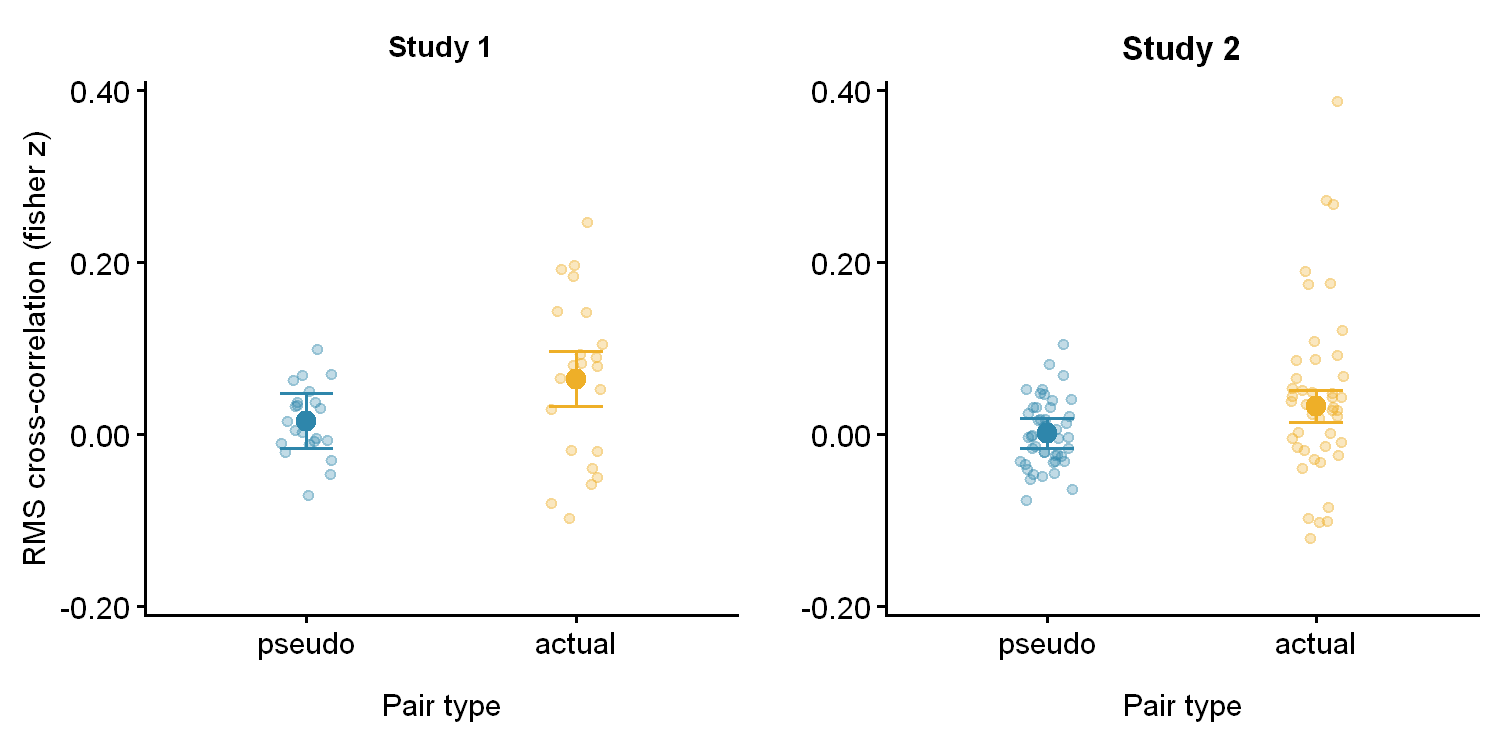

In [8]:
# Combine plots using helper function
p_rms_cat_combined <- combine_study_plots(
  plot1 = p_rms_cat_s1,
  plot2 = p_rms_cat_s2,
  filename = "figures/supplementary/combined_rms_cor_env_by_categorical.png"
)

print(p_rms_cat_combined)

## 4. Complexity Matching & Background Noise

### 4.1 Study 1: CM ~ Pair Type x Environment x Condition

In [9]:
# Model 
m1_cm_cont <- lmer(alpha_corr_z ~ condition * pair_type * environment_cent + (1 + condition | pair), data = cm_df1_env)
summary(m1_cm_cont)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: alpha_corr_z ~ condition * pair_type * environment_cent + (1 +  
    condition | pair)
   Data: cm_df1_env

REML criterion at convergence: 125.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.6376 -0.5922 -0.0130  0.5862  3.7845 

Random effects:
 Groups   Name              Variance Std.Dev. Corr
 pair     (Intercept)       0.003522 0.05934      
          conditionstanding 0.003511 0.05926  0.28
 Residual                   0.061921 0.24884      
Number of obs: 616, groups:  pair, 22

Fixed effects:
                                                     Estimate Std. Error
(Intercept)                                        -3.186e-04  2.371e-02
conditionstanding                                   8.127e-02  3.104e-02
pair_typeactual                                     4.749e-02  2.836e-02
environment_cent                                    2.564e-03  1.641e-03
conditionstanding:

### 4.2 Study 2: CM ~ Pair Type x Environment

In [10]:
# Model
m2_cm_cont <- lmer(alpha_corr_z ~ pair_type * environment_cent + (1 | pair), data = cm_df2_env)
summary(m2_cm_cont)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: alpha_corr_z ~ pair_type * environment_cent + (1 | pair)
   Data: cm_df2_env

REML criterion at convergence: -554.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.1014 -0.6003  0.0374  0.5982  3.4921 

Random effects:
 Groups   Name        Variance Std.Dev.
 pair     (Intercept) 0.001064 0.03262 
 Residual             0.017244 0.13132 
Number of obs: 502, groups:  pair, 46

Fixed effects:
                                   Estimate Std. Error         df t value
(Intercept)                       2.030e-02  9.312e-03  1.011e+02   2.179
pair_typeactual                   8.642e-03  1.185e-02  4.731e+02   0.729
environment_cent                  3.000e-04  7.348e-04  4.553e+02   0.408
pair_typeactual:environment_cent -1.707e-03  1.101e-03  4.599e+02  -1.550
                                 Pr(>|t|)  
(Intercept)                        0.0316 *
pair_typeactual                    0.4

## 5. RMS Cross-Correlation & Background Noise

### 5.1 Study 1: RMS Cor ~ Pair Type x Environment x Condition

In [11]:
# Model
## Pair random effect shows singular fit (consistent with categorical model)
m1_rms_cont <- lmer(rms_corr_z ~ condition * environment_cent * pair_type + (1 | pair), data = cm_df1_env)
summary(m1_rms_cont)

# Using fixed effects only model instead
m1_rms_cor_cont <- lm(rms_corr_z ~ condition * pair_type * environment_cent, data = cm_df1_env)
summary(m1_rms_cor_cont)

boundary (singular) fit: see help('isSingular')



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: rms_corr_z ~ condition * environment_cent * pair_type + (1 |  
    pair)
   Data: cm_df1_env

REML criterion at convergence: 254.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.8169 -0.5022 -0.0377  0.5388  3.7147 

Random effects:
 Groups   Name        Variance Std.Dev.
 pair     (Intercept) 0.00000  0.0000  
 Residual             0.08062  0.2839  
Number of obs: 616, groups:  pair, 22

Fixed effects:
                                                     Estimate Std. Error
(Intercept)                                        -6.833e-03  2.288e-02
conditionstanding                                   4.468e-02  3.236e-02
environment_cent                                    9.692e-04  1.873e-03
pair_typeactual                                     3.103e-02  3.236e-02
conditionstanding:environment_cent                 -1.924e-05  2.649e-03
conditionstanding:pair_typeactual          


Call:
lm(formula = rms_corr_z ~ condition * pair_type * environment_cent, 
    data = cm_df1_env)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.08374 -0.14259 -0.01071  0.15297  1.05473 

Coefficients:
                                                     Estimate Std. Error
(Intercept)                                        -6.833e-03  2.288e-02
conditionstanding                                   4.468e-02  3.236e-02
pair_typeactual                                     3.103e-02  3.236e-02
environment_cent                                    9.692e-04  1.873e-03
conditionstanding:pair_typeactual                   3.617e-02  4.576e-02
conditionstanding:environment_cent                 -1.924e-05  2.649e-03
pair_typeactual:environment_cent                    5.371e-04  2.649e-03
conditionstanding:pair_typeactual:environment_cent -5.491e-03  3.746e-03
                                                   t value Pr(>|t|)
(Intercept)                                         -0.29

### 5.2 Study 2: RMS Cor ~ Pair Type x Environment

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: rms_corr_z ~ pair_type * environment_cent + (1 | pair)
   Data: cm_df2_env

REML criterion at convergence: -545.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9342 -0.6231 -0.0462  0.5586  3.2328 

Random effects:
 Groups   Name        Variance  Std.Dev.
 pair     (Intercept) 0.0006136 0.02477 
 Residual             0.0178443 0.13358 
Number of obs: 502, groups:  pair, 46

Fixed effects:
                                   Estimate Std. Error         df t value
(Intercept)                       1.747e-03  8.892e-03  1.108e+02   0.196
pair_typeactual                   2.991e-02  1.203e-02  4.736e+02   2.487
environment_cent                  8.795e-04  7.475e-04  4.534e+02   1.177
pair_typeactual:environment_cent -2.927e-03  1.120e-03  4.590e+02  -2.615
                                 Pr(>|t|)   
(Intercept)                       0.84460   
pair_typeactual                   0

,pair_type,environment_cent.trend,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,pseudo,0.0008794712,0.0007475115,454.0789,-0.000589540,0.0023484823,1.176532,0.23999879
2,actual,-0.0020480079,0.0008338927,463.7591,-0.003686684,-0.0004093318,-2.455961,0.01441655


 contrast        estimate      SE  df t.ratio p.value
 pseudo - actual  0.00293 0.00112 460   2.614  0.0092

Degrees-of-freedom method: kenward-roger 

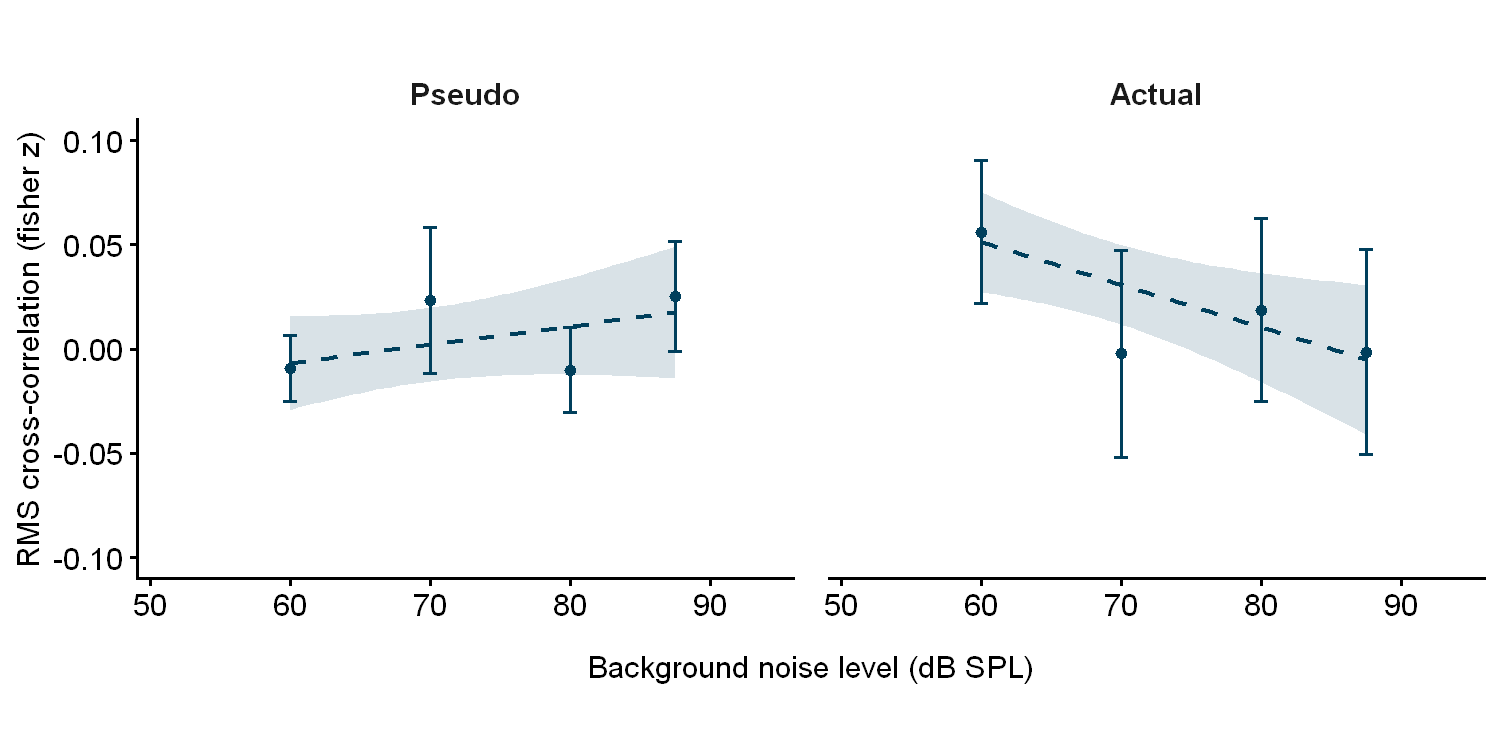

In [12]:
# Model 
m2_rms_cor_cont <- lmer(rms_corr_z ~ pair_type * environment_cent + (1 | pair), data = cm_df2_env)
summary(m2_rms_cor_cont)

# Estimated marginal means
emm_s2_rms_cor_cont <- emmeans(
  m2_rms_cor_cont, ~ pair_type * environment_cent,
  at = list(environment_cent = seq(
    min(cm_df2_env$environment_num, na.rm = TRUE) - mean(cm_df2_env$environment_num, na.rm = TRUE),
    max(cm_df2_env$environment_num, na.rm = TRUE) - mean(cm_df2_env$environment_num, na.rm = TRUE),
    length.out = 50
  )),
  infer = c(TRUE, TRUE)
)
emm_s2_rms_cor_cont_df <- as.data.frame(emm_s2_rms_cor_cont)

# Map to SPL scale
emm_s2_rms_cor_cont_df <- map_emm_to_spl(emm_s2_rms_cor_cont_df, study2_config, cm_df2_env)

# Test slopes (emtrends)
emtrends_s2_rms_cor <- emtrends(m2_rms_cor_cont, ~ pair_type, var = "environment_cent", infer = c(TRUE, TRUE))
emtrends_s2_rms_cor_df <- as.data.frame(emtrends_s2_rms_cor)
emtrends_s2_rms_cor_df

# Pairwise slope comparisons
pairs(emtrends_s2_rms_cor, by = NULL, adjust = "tukey")

# Create plot using helper function
p_rms_cor_cont_s2 <- create_continuous_pair_type_plot(
  dyad_data = cm_df2_env,
  value_var = "rms_corr_z",
  emm_df = emm_s2_rms_cor_cont_df,
  study_config = study2_config,
  ylabel = "RMS cross-correlation (fisher z)",
  has_condition = FALSE,
  x_breaks = seq(50, 95, by = 10),
  x_limits = c(50, 95),
  y_limits = c(-0.1, 0.1),
  output_file = "figures/supplementary/study2_rms_cor_env_by_manip.png"
)

print(p_rms_cor_cont_s2)

## 6. Complexity Matching with OIRs

### 6.1 Study 1: OIRs ~ CM × Condition × Environment

 Family: nbinom2  ( log )
Formula:          
oirs ~ alpha_corr_z * condition * environment_cent + (1 | pair)
Data: cm_df1_env_actual

      AIC       BIC    logLik -2*log(L)  df.resid 
   1139.1    1176.4    -559.5    1119.1       298 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 pair   (Intercept) 0.1734   0.4164  
Number of obs: 308, groups:  pair, 22

Dispersion parameter for nbinom2 family (): 2.47 

Conditional model:
                                                 Estimate Std. Error z value
(Intercept)                                      0.472225   0.125246   3.770
alpha_corr_z                                    -0.587713   0.273136  -2.152
conditionstanding                                0.156345   0.119853   1.304
environment_cent                                 0.044159   0.007318   6.035
alpha_corr_z:conditionstanding                   0.584723   0.380893   1.535
alpha_corr_z:environment_cent                    0.029004   0.022918   1.266
con

,environment_cent,condition,alpha_corr_z.trend,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-21.528571,sitting,-1.21213591,0.6482261,Inf,-2.4826358,0.05836393,-1.8699276,0.06149387
2,-11.228571,sitting,-0.91339073,0.4405776,Inf,-1.7769070,-0.04987447,-2.0731665,0.03815679
3,-2.828571,sitting,-0.66975388,0.3036912,Inf,-1.2649777,-0.07453005,-2.2053779,0.02742759
4,2.571429,sitting,-0.51313019,0.2566588,Inf,-1.0161722,-0.01008817,-1.9992698,0.04557917
5,5.071429,sitting,-0.44061922,0.2530726,Inf,-0.9366325,0.05539401,-1.7410782,0.08166988
6,10.471429,sitting,-0.28399554,0.2872341,Inf,-0.8469641,0.27897304,-0.9887249,0.32279778
7,17.471429,sitting,-0.08096483,0.3898971,Inf,-0.8451491,0.68321941,-0.2076569,0.83549685
8,-21.528571,standing,0.66329872,0.6589086,Inf,-0.6281383,1.95473578,1.0066628,0.31409686
9,-11.228571,standing,0.34452368,0.4458945,Inf,-0.5294135,1.21846085,0.7726574,0.43972517


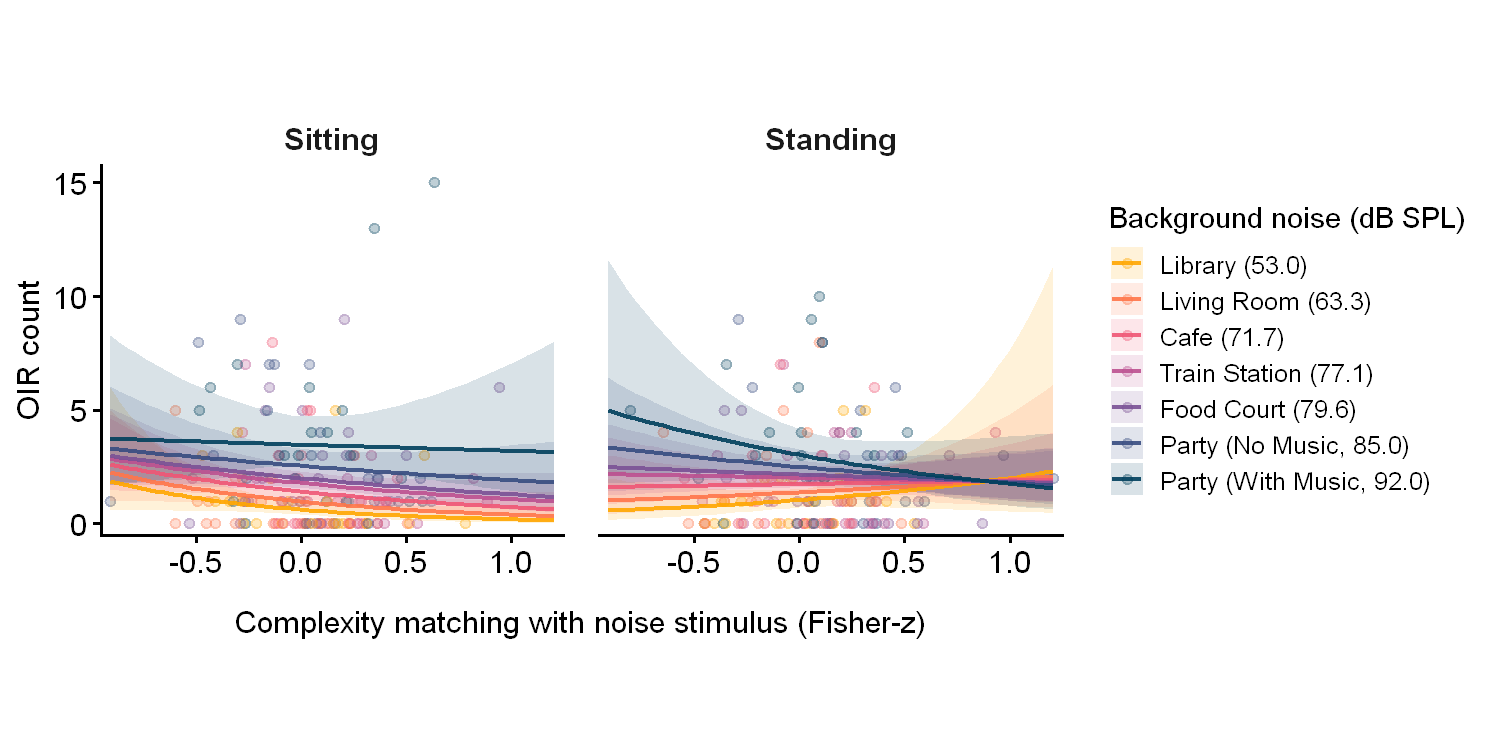

In [13]:
# Filter to actual pairs
cm_df1_env_actual <- cm_df1_env %>% filter(pair_type == "actual")

# Model
m1_oirs_cm_stim <- glmmTMB(
  oirs ~ alpha_corr_z * condition * environment_cent + (1 | pair),
  family = nbinom2,
  data = cm_df1_env_actual
)
summary(m1_oirs_cm_stim)

# Get the 7 unique environment_cent values
env_mapping <- cm_df1_env_actual %>%
  group_by(environment, environment_cent) %>%
  summarise(.groups = "drop") %>%
  arrange(environment_cent)

# Test slopes of alpha_corr_z at each environment level, by condition
slopes1_cm_oirs_stim <- emtrends(
  m1_oirs_cm_stim,
  ~ environment_cent | condition,
  var = "alpha_corr_z",
  at = list(environment_cent = env_mapping$environment_cent),
  type = "response"
)

# Display slopes with confidence intervals
summary(slopes1_cm_oirs_stim, infer = c(TRUE, TRUE))

# Create plot using helper function
p_oirs_cm_s1 <- plot_oirs_by_environment(
  model = m1_oirs_cm_stim,
  data = cm_df1_env_actual,
  predictor_cent = "alpha_corr_z",
  predictor_raw  = "alpha_corr_z",
  env_mapping = env_mapping,
  has_condition = TRUE,
  xlabel = "Complexity matching with noise stimulus (Fisher-z)",
  #cap = 15,
  ybreaks = 5,
  ylim_max = 15,
  output_file = "figures/supplementary/study1_oirs_by_cm_env.png"
)

print(p_oirs_cm_s1)

### 6.2 Study 2: OIRs ~ CM x Environment

In [14]:
# Filter to actual pairs
cm_df2_env_actual <- cm_df2_env %>% filter(pair_type == "actual")

# Model
m2_oirs_cm_stim <- glmmTMB(
  oirs ~ alpha_corr_z * environment_cent + (1 | pair),
  family = nbinom2,
  data = cm_df2_env_actual
)
summary(m2_oirs_cm_stim)

 Family: nbinom2  ( log )
Formula:          oirs ~ alpha_corr_z * environment_cent + (1 | pair)
Data: cm_df2_env_actual

      AIC       BIC    logLik -2*log(L)  df.resid 
    941.0     961.7    -464.5     929.0       224 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 pair   (Intercept) 0.5046   0.7104  
Number of obs: 230, groups:  pair, 44

Dispersion parameter for nbinom2 family (): 10.5 

Conditional model:
                               Estimate Std. Error z value Pr(>|z|)    
(Intercept)                    0.791531   0.124686   6.348 2.18e-10 ***
alpha_corr_z                   0.051188   0.338307   0.151    0.880    
environment_cent               0.084355   0.004337  19.448  < 2e-16 ***
alpha_corr_z:environment_cent -0.031050   0.030472  -1.019    0.308    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

## 7. RMS Cross-Correlation with OIRs

### 7.1 Study 1: OIRs ~ RMS Corr × Condition × Environment

 Family: nbinom2  ( log )
Formula:          oirs ~ rms_corr_z * condition * environment_cent + (1 | pair)
Data: cm_df1_env_actual

      AIC       BIC    logLik -2*log(L)  df.resid 
   1135.5    1172.8    -557.8    1115.5       298 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 pair   (Intercept) 0.183    0.4278  
Number of obs: 308, groups:  pair, 22

Dispersion parameter for nbinom2 family (): 2.52 

Conditional model:
                                               Estimate Std. Error z value
(Intercept)                                    0.455154   0.126065   3.610
rms_corr_z                                    -0.295052   0.255072  -1.157
conditionstanding                              0.098944   0.122438   0.808
environment_cent                               0.044736   0.007320   6.111
rms_corr_z:conditionstanding                   0.426944   0.358710   1.190
rms_corr_z:environment_cent                    0.043628   0.018354   2.377
conditionstanding:en

,environment_cent,condition,rms_corr_z.trend,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-21.528571,sitting,-1.23430520,0.5691651,Inf,-2.34984839,-0.118762011,-2.16862401,0.03011124
2,-11.228571,sitting,-0.78493466,0.4014051,Inf,-1.57167422,0.001804894,-1.95546754,0.05052791
3,-2.828571,sitting,-0.41845772,0.2850554,Inf,-0.97715596,0.140240529,-1.46798752,0.14210761
4,2.571429,sitting,-0.18286540,0.2345563,Inf,-0.64258727,0.276856483,-0.77962265,0.43561302
5,5.071429,sitting,-0.07379488,0.2225355,Inf,-0.50995646,0.362366707,-0.33160944,0.74018419
6,10.471429,sitting,0.16179745,0.2280905,Inf,-0.28525178,0.608846669,0.70935626,0.47810342
7,17.471429,sitting,0.46719490,0.2907094,Inf,-0.10258508,1.036974877,1.60708556,0.10803560
8,-21.528571,standing,1.08795229,0.5917524,Inf,-0.07186103,2.247765617,1.83852630,0.06598489
9,-11.228571,standing,0.63054030,0.4017230,Inf,-0.15682227,1.417902873,1.56958983,0.11651057


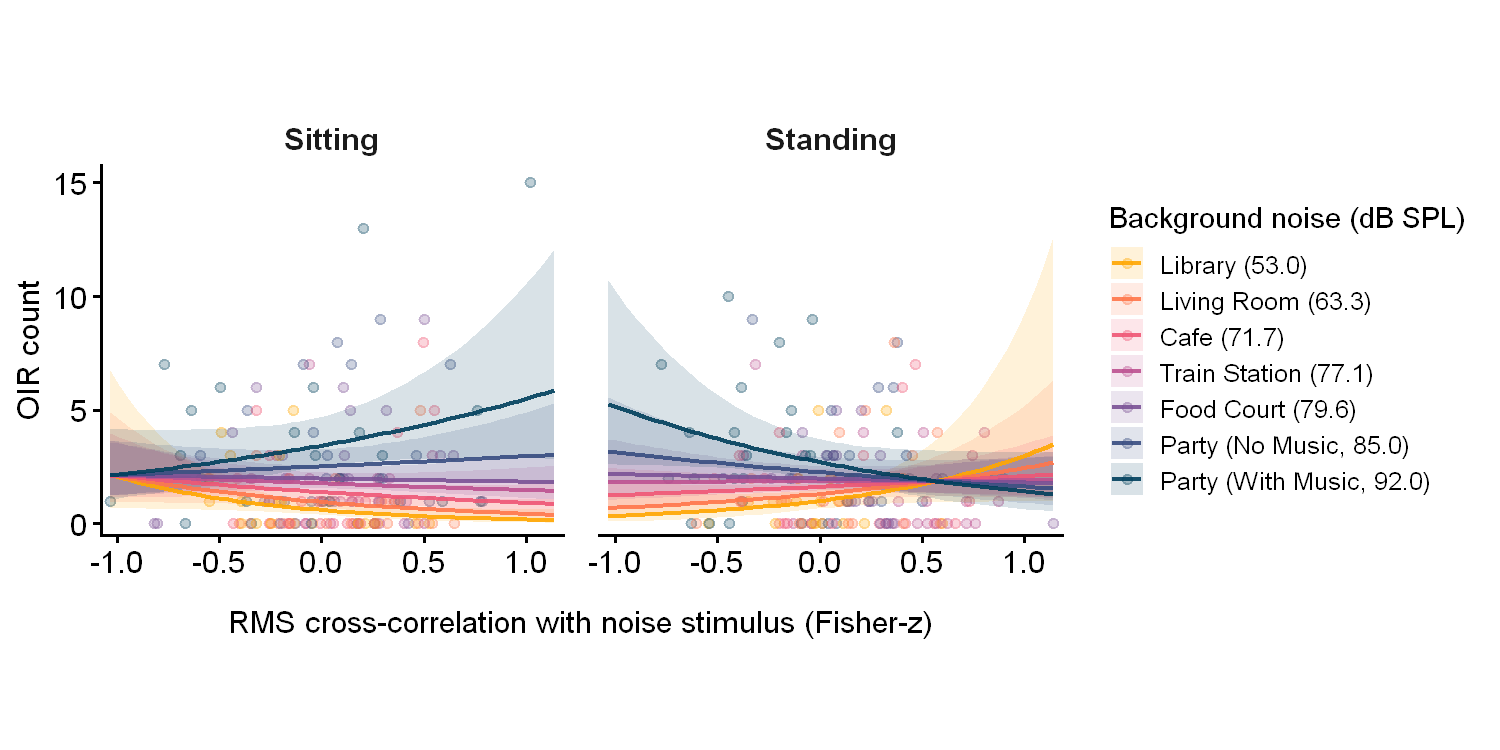

In [15]:
# Filter to actual pairs
cm_df1_env_actual <- cm_df1_env %>% filter(pair_type == "actual")

# Model
m1_oirs_rms_cor_stim <- glmmTMB(
  oirs ~ rms_corr_z * condition * environment_cent + (1 | pair),
  family = nbinom2,
  data = cm_df1_env_actual
)
summary(m1_oirs_rms_cor_stim)

# Get the 7 unique environment_cent values
env_mapping <- cm_df1_env_actual %>%
  group_by(environment, environment_cent) %>%
  summarise(.groups = "drop") %>%
  arrange(environment_cent)

# Test slopes of rms_corr_z at each environment level, by condition
slopes1_rms_cor_oirs_stim <- emtrends(
  m1_oirs_rms_cor_stim,
  ~ environment_cent | condition,
  var = "rms_corr_z",
  at = list(environment_cent = env_mapping$environment_cent),
  type = "response"
)

# Display slopes with confidence intervals
summary(slopes1_rms_cor_oirs_stim, infer = c(TRUE, TRUE))

# Create plot using helper function
p_oirs_rms_cor_s1 <- plot_oirs_by_environment(
  model = m1_oirs_rms_cor_stim,
  data = cm_df1_env_actual,
  predictor_cent = "rms_corr_z",
  predictor_raw  = "rms_corr_z",
  env_mapping = env_mapping,
  has_condition = TRUE,
  xlabel = "RMS cross-correlation with noise stimulus (Fisher-z)",
  #cap = 15,
  ybreaks = 5,
  ylim_max = 15,
  output_file = "figures/supplementary/study1_oirs_by_rms_cor_env.png"
)

print(p_oirs_rms_cor_s1)

### 7.2 Study 2: OIRs ~ RMS Corr × Environment

 Family: nbinom2  ( log )
Formula:          oirs ~ rms_corr_z * environment_cent + (1 | pair)
Data: cm_df2_env_actual

      AIC       BIC    logLik -2*log(L)  df.resid 
    932.7     953.3    -460.4     920.7       224 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 pair   (Intercept) 0.5225   0.7228  
Number of obs: 230, groups:  pair, 44

Dispersion parameter for nbinom2 family (): 12.7 

Conditional model:
                             Estimate Std. Error z value Pr(>|z|)    
(Intercept)                  0.778850   0.126314   6.166    7e-10 ***
rms_corr_z                  -0.277521   0.309554  -0.897  0.36998    
environment_cent             0.084542   0.004227  19.999  < 2e-16 ***
rms_corr_z:environment_cent -0.075620   0.026632  -2.839  0.00452 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

,environment_cent,rms_corr_z.trend,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-9.5863636,0.4474013,0.4196872,Inf,-0.3751706,1.2699732,1.066035,0.286407800
2,0.4136364,-0.3087998,0.3086936,Inf,-0.9138282,0.2962285,-1.000344,0.317143996
3,10.4136364,-1.0650010,0.3953478,Inf,-1.8398684,-0.2901336,-2.693833,0.007063549
4,17.9136364,-1.6321519,0.5432748,Inf,-2.6969508,-0.5673529,-3.004284,0.002662065


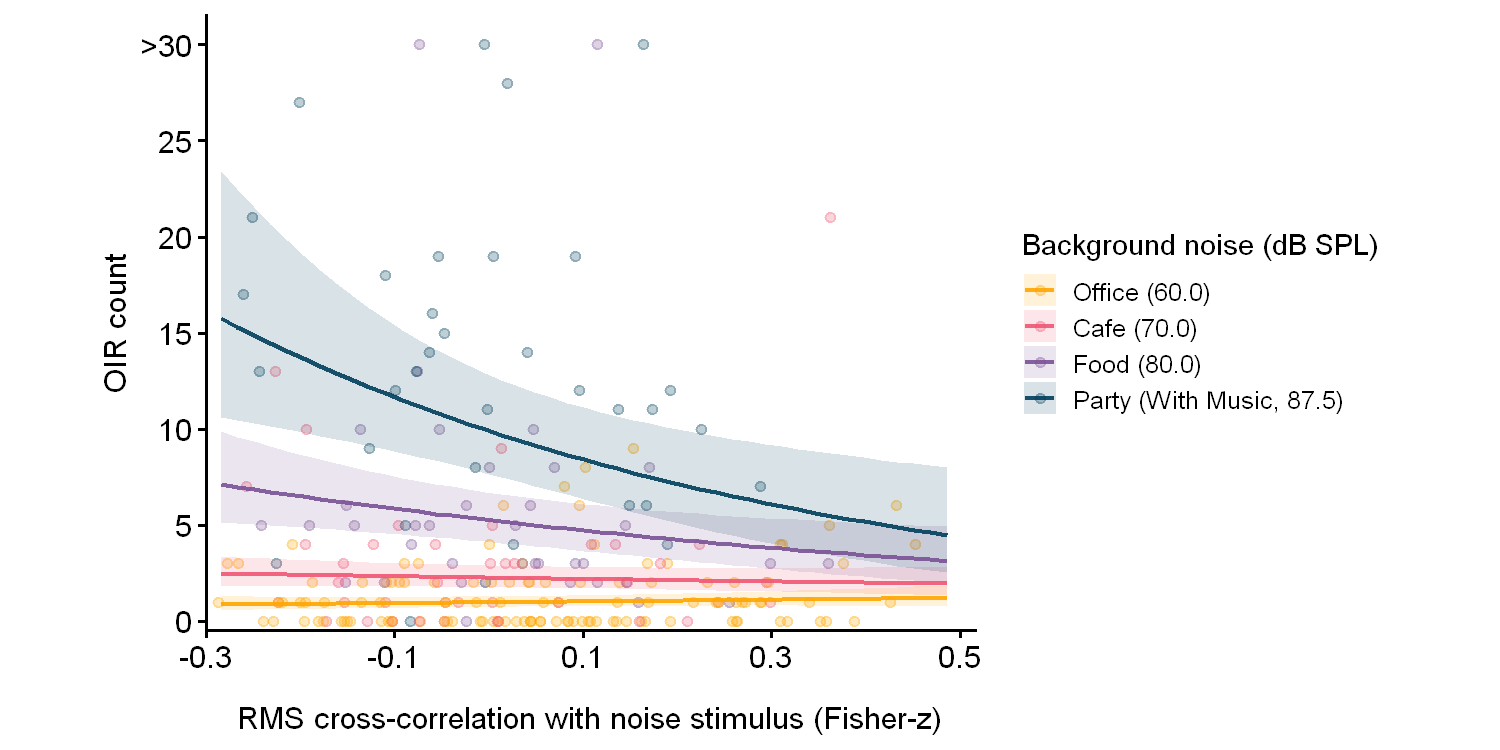

In [16]:
# Filter to actual pairs
cm_df2_env_actual <- cm_df2_env %>% filter(pair_type == "actual")

# Model
m2_oirs_rms_cor_stim <- glmmTMB(
  oirs ~ rms_corr_z * environment_cent + (1 | pair),
  family = nbinom2,
  data = cm_df2_env_actual
)
summary(m2_oirs_rms_cor_stim)

# Get the 4 unique environment_cent values
env_mapping <- cm_df2_env_actual %>%
  group_by(environment, environment_cent) %>%
  summarise(.groups = "drop") %>%
  arrange(environment_cent)

# Test slopes of rms_corr_z at each environment level, by condition
slopes2_rms_cor_oirs_stim <- emtrends(
  m2_oirs_rms_cor_stim,
  ~ environment_cent,
  var = "rms_corr_z",
  at = list(environment_cent = env_mapping$environment_cent),
  type = "response"
)

# Display slopes with confidence intervals
summary(slopes2_rms_cor_oirs_stim, infer = c(TRUE, TRUE))

# Create plot using helper function
p_oirs_rms_cor_s2 <- plot_oirs_by_environment(
  model = m2_oirs_rms_cor_stim,
  data = cm_df2_env_actual,
  predictor_cent = "rms_corr_z",
  predictor_raw  = "rms_corr_z",
  env_mapping = env_mapping,
  has_condition = FALSE,
  xlabel = "RMS cross-correlation with noise stimulus (Fisher-z)",
  cap = 30,
  ybreaks = 5,
  ylim_max = 30,
  x_limits      = c(-0.30, 0.50),
  output_file = "figures/supplementary/study2_oirs_by_rms_cor_env.png"
)

print(p_oirs_rms_cor_s2)